# Notebook 17 — NSV Data Preparation (BSISO, MJJAS, consecutive-day pairs)
**Project:** ENSO-BSISO Self-Supervised Learning — Neural State Variables extension  
**Author:** Jiayi (jh9141@nyu.edu)

Stage 0 of the NSV pipeline (Chen et al., arXiv:2112.10755). The Stage 1 encoder-decoder (nb18) needs consecutive-day pairs `(X_t, X_{t+1})` of preprocessed atmospheric fields. This notebook builds those pairs from the existing MJJAS Lee-preprocessed data and produces the inputs nb18 will consume.

## Design decisions (Session 26 plan §7, revised after debugging)

| Knob | Value | Why |
|---|---|---|
| Source | `X_MJJAS_lee.npy` + `labels_aligned_mjjas_lee_clean.csv` (Lee preprocessing, cleaned by nb03b) | The BSISO project's standard Lee-preprocessed MJJAS tensor. Keeps ENSO modulation present so we can detect it in the latent ID (otherwise Hypothesis H2 is foreclosed by construction). Same data nb07c/nb08 used for the proven BSISO SSL results. |
| Channels | `[u850, v850, OLR]` order from nb03 | unchanged |
| Spatial domain | 60°E–160°E, 0–60°N at 2° → `(3, 31, 51)` per day | unchanged |
| Temporal scope | **MJJAS** (May 1 – September 30) | ~6,688 pairs (44 years × ~152 valid intra-year pairs). 5× more than July-only, comfortable Levina-Bickel sample size (`k ≈ 67` at 1% of N). Session 26 §6 originally said "extend to MJJAS if July is too noisy" — we just start at MJJAS now since the data already exists. |
| Pair definition | `(X[i], X[i+1])` valid iff `dates[i+1] = dates[i] + 1 day` AND same calendar year | Year-boundary gaps (Sep 30 → May 1 next year) are excluded by both the day-delta and same-year tests. Within MJJAS each year has 152 valid intra-year transitions. |
| Train/val split | Year-based; hold out every 5th year (1983, 1988, 1993, 1998, 2003, 2008, 2013, 2018, 2023) | Consistent with nb04/nb07c/nb08. Within-year pairs only, so each year's pairs go entirely to one split. |

## Outputs (`BSISO_SSL_Project/nsv/data/`)

- `X_t.npy` shape `(N_pairs, 3, 31, 51)` float32 — current-day fields
- `X_t1.npy` shape `(N_pairs, 3, 31, 51)` float32 — next-day fields
- `dates_t.npy` shape `(N_pairs,)` datetime64 — date of each anchor day
- `bsiso_phase_t.npy` shape `(N_pairs,)` int — BSISO phase aligned to anchor
- `bsiso_amplitude_t.npy` shape `(N_pairs,)` float — BSISO amplitude aligned to anchor
- `enso_cat_t.npy` shape `(N_pairs,)` `<U10` — ENSO category aligned to anchor
- `train_mask.npy` shape `(N_pairs,)` bool — True if pair's year ∈ train split
- `nsv_data_meta.json` — pair counts + split summary + reproducibility metadata

## Verification gate (must pass before nb18)
1. **No cross-year pairs.** Assert `max(dates_t1 - dates_t) == 1 day`.
2. **Expected pair count.** Total ≈ 6,688 (44 × 152); allow [44 × 145, 44 × 152] for any missing days.
3. **Visual coherence.** Three random `(X_t, X_t1)` pairs side-by-side as OLR maps look like adjacent days.
4. **ENSO balance.** Train and val sets both contain EN, Neutral, and LN years.

## Runtime
~2–3 min on Colab T4 (mostly Drive I/O; ~500 MB of paired tensors on disk).

---

## Cell 1 — Mount Drive + Constants

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR    = '/content/drive/MyDrive/BSISO_SSL_Project'
PROCESSED_DIR  = f'{PROJECT_DIR}/data/processed'
NSV_DIR        = f'{PROJECT_DIR}/nsv'
NSV_DATA_DIR   = f'{NSV_DIR}/data'
os.makedirs(NSV_DATA_DIR, exist_ok=True)

X_FILE      = 'X_MJJAS_lee.npy'                     # MJJAS Lee preprocessing — same as nb07c/nb08
LABELS_FILE = 'labels_aligned_mjjas_lee_clean.csv'  # nb03b-cleaned amplitude column (matches nb08)

# Year-based split (every 5th year held out) — matches nb04/nb07c/nb08
VAL_YEARS_STRIDE = 5

print(f'Project dir:  {PROJECT_DIR}')
print(f'Source:       {PROCESSED_DIR}/{X_FILE}')
print(f'Labels:       {PROCESSED_DIR}/{LABELS_FILE}')
print(f'Output dir:   {NSV_DATA_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project dir:  /content/drive/MyDrive/BSISO_SSL_Project
Source:       /content/drive/MyDrive/BSISO_SSL_Project/data/processed/X_MJJAS_lee.npy
Labels:       /content/drive/MyDrive/BSISO_SSL_Project/data/processed/labels_aligned_mjjas_lee_clean.csv
Output dir:   /content/drive/MyDrive/BSISO_SSL_Project/nsv/data


## Cell 2 — Load Data, Build Consecutive Pairs, Year-Based Split, Save

All the data work in one cell. The pair-construction logic is the single load-bearing step:

1. Load `X_July.npy` and `labels.csv`; assert lengths match.
2. Sort by date (defensive — should already be sorted by nb03).
3. For each `i ∈ [0, N-2]`, mark `i` as the **start of a valid pair** iff `dates[i+1] - dates[i] = 1 day` AND `year(dates[i]) = year(dates[i+1])`. The year check excludes year-boundary jumps (Jul 31 → Jul 1 next year).
4. Build `X_t`, `X_t1` arrays by indexing with the valid-start positions and `+1` of them.
5. Year-based split: a pair belongs to `year(dates[i])` (= year of anchor day, equal to year of next day by construction). Held-out years are `years[::VAL_YEARS_STRIDE]`.
6. Save all eight outputs.

In [5]:
X = np.load(f'{PROCESSED_DIR}/{X_FILE}')
labels = pd.read_csv(f'{PROCESSED_DIR}/{LABELS_FILE}', parse_dates=['date'])
labels['date'] = labels['date'].dt.normalize()

assert X.shape[0] == len(labels), f'X / labels length mismatch: {X.shape[0]} vs {len(labels)}'
assert X.shape[1:] == (3, 31, 51), f'Unexpected X shape: {X.shape[1:]}; expected (3, 31, 51).'
print(f'Raw load:  X shape {X.shape}, {len(labels)} labels.  Date range {labels["date"].min().date()} to {labels["date"].max().date()}.')

# Defensive sort + reset (should be no-op if nb03 wrote in order)
order = np.argsort(labels['date'].values)
if not np.array_equal(order, np.arange(len(labels))):
    print(f'WARN: labels not pre-sorted — reordering X and labels.')
    X = X[order]
    labels = labels.iloc[order].reset_index(drop=True)

dates_all = pd.DatetimeIndex(labels['date'].values)
years_all = dates_all.year.values

# Build valid-pair-start mask. valid[i]=True means (X[i], X[i+1]) is a valid pair.
delta_days = (dates_all[1:] - dates_all[:-1]).days
same_year  = years_all[1:] == years_all[:-1]
valid_start = (delta_days == 1) & same_year
valid_start = np.concatenate([valid_start, [False]])     # length N; last position can never be a pair-start

pair_idx_t  = np.where(valid_start)[0]
pair_idx_t1 = pair_idx_t + 1
N_pairs = len(pair_idx_t)
print(f'\nPair construction:  {N_pairs} valid consecutive-day pairs (expected ~6,688 for 44 yrs × 152 pairs/yr).')

# Build arrays
X_t  = X[pair_idx_t].astype(np.float32)
X_t1 = X[pair_idx_t1].astype(np.float32)
dates_t          = dates_all[pair_idx_t]
bsiso_phase_t    = labels['bsiso_phase'].values[pair_idx_t].astype(np.int8)
bsiso_amplitude_t = labels['bsiso_amplitude'].values[pair_idx_t].astype(np.float32)
enso_cat_t       = labels['enso_category'].values[pair_idx_t].astype('<U10')

# Year-based train/val split (every Vth year)
pair_years  = dates_t.year.values
all_years   = sorted(np.unique(years_all).tolist())
val_years   = all_years[::VAL_YEARS_STRIDE]
train_years = sorted(set(all_years) - set(val_years))
train_mask  = np.isin(pair_years, train_years)

n_train = int(train_mask.sum())
n_val   = int((~train_mask).sum())
print(f'Train: {n_train} pairs ({100*n_train/N_pairs:.1f}%)  from {len(train_years)} years')
print(f'Val:   {n_val} pairs ({100*n_val/N_pairs:.1f}%)  from {len(val_years)} years: {val_years}')

# Save
np.save(f'{NSV_DATA_DIR}/X_t.npy', X_t)
np.save(f'{NSV_DATA_DIR}/X_t1.npy', X_t1)
np.save(f'{NSV_DATA_DIR}/dates_t.npy', dates_t.values.astype('datetime64[D]'))
np.save(f'{NSV_DATA_DIR}/bsiso_phase_t.npy', bsiso_phase_t)
np.save(f'{NSV_DATA_DIR}/bsiso_amplitude_t.npy', bsiso_amplitude_t)
np.save(f'{NSV_DATA_DIR}/enso_cat_t.npy', enso_cat_t)
np.save(f'{NSV_DATA_DIR}/train_mask.npy', train_mask)

meta = {
    'source_X':         X_FILE,
    'source_labels':    LABELS_FILE,
    'channels':         ['u850', 'v850', 'OLR'],
    'spatial_shape':    list(X.shape[1:]),
    'temporal_scope':   'MJJAS (May 1 – September 30), Lee preprocessing',
    'pair_rule':        'dates[i+1] = dates[i] + 1d  AND  same calendar year',
    'n_pairs_total':    int(N_pairs),
    'n_pairs_train':    int(n_train),
    'n_pairs_val':      int(n_val),
    'train_years':      [int(y) for y in train_years],
    'val_years':        [int(y) for y in val_years],
    'val_year_stride':  int(VAL_YEARS_STRIDE),
    'date_min':         str(dates_t.min().date()),
    'date_max':         str(dates_t.max().date()),
}
with open(f'{NSV_DATA_DIR}/nsv_data_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print(f'\nSaved 7 .npy files + nsv_data_meta.json to {NSV_DATA_DIR}')
for name in ['X_t', 'X_t1', 'dates_t', 'bsiso_phase_t', 'bsiso_amplitude_t', 'enso_cat_t', 'train_mask']:
    p = f'{NSV_DATA_DIR}/{name}.npy'
    print(f'  {name+".npy":<26s}  {os.path.getsize(p)/1e6:7.2f} MB')

Raw load:  X shape (6579, 3, 31, 51), 6579 labels.  Date range 1981-05-01 to 2023-09-30.

Pair construction:  6536 valid consecutive-day pairs (expected ~6,688 for 44 yrs × 152 pairs/yr).
Train: 5168 pairs (79.1%)  from 34 years
Val:   1368 pairs (20.9%)  from 9 years: [1981, 1986, 1991, 1996, 2001, 2006, 2011, 2016, 2021]

Saved 7 .npy files + nsv_data_meta.json to /content/drive/MyDrive/BSISO_SSL_Project/nsv/data
  X_t.npy                      124.00 MB
  X_t1.npy                     124.00 MB
  dates_t.npy                    0.05 MB
  bsiso_phase_t.npy              0.01 MB
  bsiso_amplitude_t.npy          0.03 MB
  enso_cat_t.npy                 0.26 MB
  train_mask.npy                 0.01 MB


## Cell 3 — Verification Gate

All four checks from the title cell, run as hard assertions where possible. If any fail, **do not proceed to nb18**.

In [6]:
# 1. No cross-year pairs (the load-bearing assertion)
next_dates = dates_all[pair_idx_t1]
deltas = (next_dates - dates_t).days
assert deltas.min() == 1 and deltas.max() == 1, f'Cross-year pair detected! min={deltas.min()}, max={deltas.max()}'
assert (next_dates.year.values == dates_t.year.values).all(), 'Year mismatch in some pair!'
print(f'✓ All {N_pairs} pairs have delta = 1 day and same year.')

# 2. Pair count is in the expected range (MJJAS: 153 days/year → 152 valid intra-year transitions)
expected_lo, expected_hi = 44 * 145, 44 * 152   # tolerate a few missing days
assert expected_lo <= N_pairs <= expected_hi, f'Pair count {N_pairs} outside expected range [{expected_lo}, {expected_hi}]'
print(f'✓ Pair count {N_pairs} within expected range [{expected_lo}, {expected_hi}].')

# 3. No NaN in saved arrays
assert not np.isnan(X_t).any() and not np.isnan(X_t1).any(), 'NaN in X_t or X_t1!'
print(f'✓ No NaN in X_t or X_t1.')

# 4. ENSO balance check — each split should see all three categories
print('\nENSO category balance (anchor-day basis):')
print(f'  {"split":<6} {"El Nino":>9} {"Neutral":>9} {"La Nina":>9}  total')
for split_name, mask in [('train', train_mask), ('val', ~train_mask)]:
    cats = enso_cat_t[mask]
    n_en = int((cats == 'El Nino').sum())
    n_nu = int((cats == 'Neutral').sum())
    n_ln = int((cats == 'La Nina').sum())
    print(f'  {split_name:<6} {n_en:9d} {n_nu:9d} {n_ln:9d}  {mask.sum():5d}')
    assert n_en > 0 and n_nu > 0 and n_ln > 0, f'{split_name} split missing an ENSO category!'
print('✓ Both splits contain all three ENSO categories.')

# 5. BSISO phase coverage (informational; not asserted)
print('\nBSISO phase distribution (anchor-day basis):')
for split_name, mask in [('train', train_mask), ('val', ~train_mask)]:
    phases = bsiso_phase_t[mask]
    counts = [int((phases == p).sum()) for p in range(1, 9)]
    print(f'  {split_name:<6} ' + ' '.join(f'P{p}={c:4d}' for p, c in zip(range(1, 9), counts)))

# 6. Per-month coverage (MJJAS-specific sanity)
print('\nPer-month coverage (anchor-day basis):')
months_t = pd.DatetimeIndex(dates_t.values).month
for split_name, mask in [('train', train_mask), ('val', ~train_mask)]:
    counts = [int(((months_t == m) & mask).sum()) for m in [5, 6, 7, 8, 9]]
    print(f'  {split_name:<6} May={counts[0]:5d}  Jun={counts[1]:5d}  Jul={counts[2]:5d}  Aug={counts[3]:5d}  Sep={counts[4]:5d}')

print('\n✓ Verification gate PASSED. Proceed to nb18 (Stage 1 encoder-decoder).')

✓ All 6536 pairs have delta = 1 day and same year.
✓ Pair count 6536 within expected range [6380, 6688].
✓ No NaN in X_t or X_t1.

ENSO category balance (anchor-day basis):
  split    El Nino   Neutral   La Nina  total
  train        912      2736      1520   5168
  val          152      1064       152   1368
✓ Both splits contain all three ENSO categories.

BSISO phase distribution (anchor-day basis):
  train  P1= 710 P2= 693 P3= 738 P4= 533 P5= 597 P6= 620 P7= 545 P8= 732
  val    P1= 168 P2= 135 P3= 207 P4= 133 P5= 185 P6= 208 P7= 154 P8= 178

Per-month coverage (anchor-day basis):
  train  May= 1054  Jun= 1020  Jul= 1054  Aug= 1054  Sep=  986
  val    May=  279  Jun=  270  Jul=  279  Aug=  279  Sep=  261

✓ Verification gate PASSED. Proceed to nb18 (Stage 1 encoder-decoder).


## Cell 4 — Visualize Three Random Pairs (OLR channel)

Sanity check that the saved pairs really do look like consecutive days. We plot OLR (channel 2) for `X_t` and `X_t1` side-by-side for three random pairs from the val split. Expect: large-scale BSISO convective patterns visible, with small day-to-day shifts (eastward / northward propagation), not random fields.

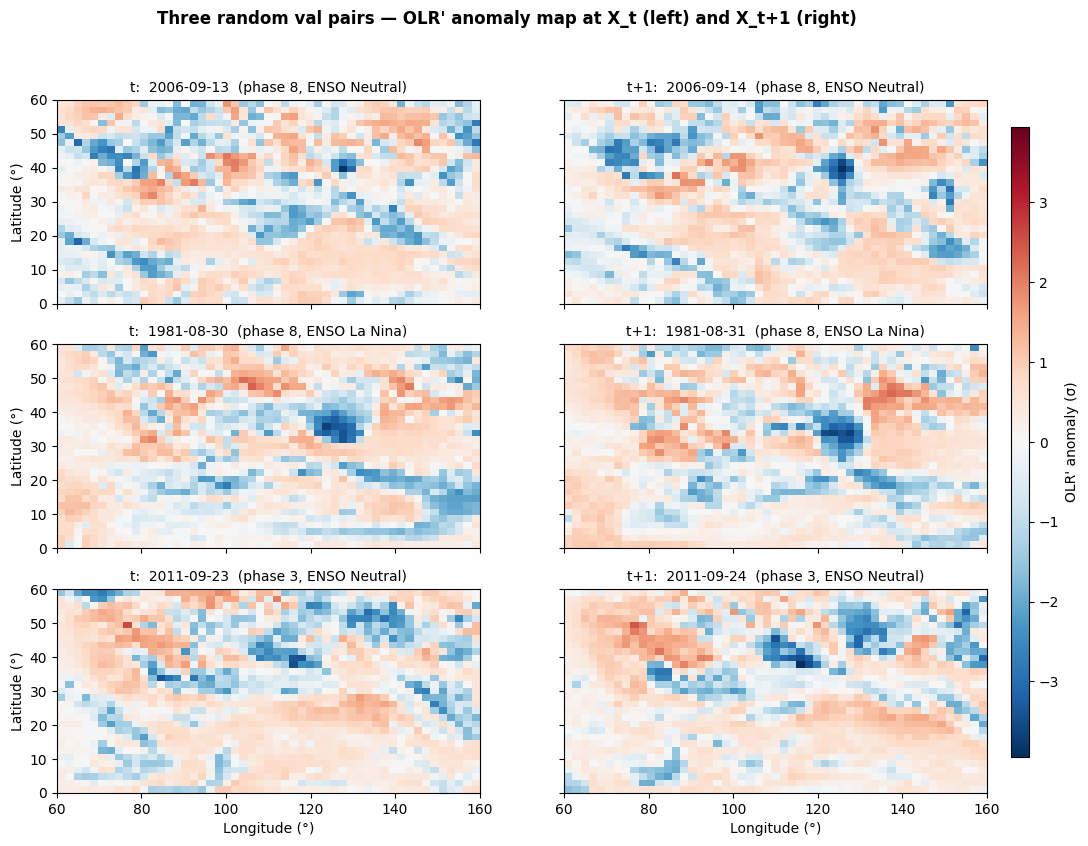

Saved: /content/drive/MyDrive/BSISO_SSL_Project/nsv/data/sample_pairs_olr.png

Visual check: each row should show two similar large-scale patterns (same row = same BSISO state, one day apart).


In [7]:
rng = np.random.default_rng(42)
val_pos = np.where(~train_mask)[0]
picks = rng.choice(val_pos, size=3, replace=False)

olr_ch = 2  # channel order is [u850, v850, OLR]
fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True, sharey=True)
fig.suptitle("Three random val pairs — OLR' anomaly map at X_t (left) and X_t+1 (right)",
             fontsize=12, fontweight='bold')

# Shared color scale across all 6 panels
vmax = max(np.abs(X_t[picks, olr_ch]).max(), np.abs(X_t1[picks, olr_ch]).max())

for row_idx, k in enumerate(picks):
    date_t  = pd.Timestamp(dates_t[k])
    date_t1 = date_t + pd.Timedelta(days=1)
    for col_idx, (Xarr, when) in enumerate([(X_t, 't'), (X_t1, 't+1')]):
        ax = axes[row_idx, col_idx]
        im = ax.imshow(Xarr[k, olr_ch], cmap='RdBu_r', aspect='auto',
                       extent=[60, 160, 0, 60], vmin=-vmax, vmax=vmax, origin='lower')
        d = date_t if when == 't' else date_t1
        ax.set_title(f"{when}:  {d.date()}  (phase {bsiso_phase_t[k]}, ENSO {enso_cat_t[k]})",
                     fontsize=10)
        if col_idx == 0: ax.set_ylabel('Latitude (°)')
        if row_idx == 2: ax.set_xlabel('Longitude (°)')

fig.subplots_adjust(right=0.90)
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
plt.colorbar(im, cax=cbar_ax, label="OLR' anomaly (σ)")
fig_path = f'{NSV_DATA_DIR}/sample_pairs_olr.png'
plt.savefig(fig_path, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')
print('\nVisual check: each row should show two similar large-scale patterns (same row = same BSISO state, one day apart).')

---
## Done!

**Send back** for review:
1. The printed output of Cell 2 — pair count, train/val sizes, file sizes.
2. The printed output of Cell 3 — verification gate (should end in `✓ Verification gate PASSED`).
3. `sample_pairs_olr.png` — visual sanity that pairs look like consecutive days.

**If everything looks right:**
- Files on Drive at `BSISO_SSL_Project/nsv/data/` will be consumed by nb18 (Stage 1 encoder-decoder).
- nb18 takes `(X_t[k], X_t1[k])` for each `k`, trains a CNN to predict `X_t1[k]` from `X_t[k]` with MSE loss, then saves the 64-D latent vector `z_t[k] = g_E(X_t[k])` for every pair. nb19 then estimates the intrinsic dimension of `{z_t}`.

**If the pair count is below ~6,000** (e.g. many years have fewer than 145 valid pairs), flag it — but at MJJAS this would be unusual since each year contributes ~152 pairs from a contiguous May-September run.

---
*DDCS Project | jh9141@nyu.edu*